# Principal Components Analysis (CS229) — Practical Implementation

## 1. Introduction

This notebook is the **practical companion** to the CS229 notes on
**Principal Components Analysis (PCA)**: normalization, the
variance-maximization derivation, principal components as eigenvectors of
the covariance matrix, dimensionality reduction, and PCA's applications
(compression/visualization, preprocessing for further analysis, and noise
reduction).

**Dataset:** `mall_customers.csv` — 200 mall customers with `CustomerID`,
`Gender`, `Age`, `Annual Income (k$)`, and `Spending Score (1-100)`. This is
the **same dataset** used earlier in this session for the K-means/EM
clustering notebook, where we manually chose 2 features (`Annual Income`,
`Spending Score`) purely because they gave a clean 2-D plot. PCA gives us a
**principled, automatic** way to do that same kind of reduction — including
information from **all** numeric features (`Age` too), not just the two we
happened to pick by eye.

**Concept implemented:** PCA as dimensionality reduction — finding the
directions of maximum variance among `Age`, `Annual Income`, and `Spending
Score`, and re-expressing each customer in terms of a smaller number of
these directions.

> ⚠️ **Scope note:** This dataset has only **3 natural numeric features** —
> much lower-dimensional than a typical PCA use case (the notes' own
> examples use hundreds or thousands of dimensions, e.g. `R^10000` for
> face images). This means aggressive "compression" isn't really the point
> here; instead, this dataset is a clean, small setting to see the
> **mechanics** of PCA precisely and verify them against the theory by
> hand. It also has **no natural supervised target** (no label to predict),
> so the notes' "preprocessing before supervised learning" application
> doesn't directly fit here. Rather than forcing an artificial
> classification task onto this data, Section 14 instead applies PCA to a
> task this dataset **does** naturally support: comparing PCA-derived
> features against hand-picked features as input to **clustering** — a
> direct, honest extension of the same underlying idea (dimensionality
> reduction as preprocessing for a downstream algorithm).

**Machine Learning task:** **Unsupervised dimensionality reduction.**


## 2. Import Libraries

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

RANDOM_STATE = 42
sns.set_theme(style="whitegrid")


## 3. Load the Dataset

In [3]:
df = pd.read_csv(r"C:\Users\img\Desktop\ML Study\Lec_11_PCA\Dataset.csv")
df.head()


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [4]:
df.shape


(200, 5)

In [5]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   CustomerID              200 non-null    int64
 1   Gender                  200 non-null    str  
 2   Age                     200 non-null    int64
 3   Annual Income (k$)      200 non-null    int64
 4   Spending Score (1-100)  200 non-null    int64
dtypes: int64(4), str(1)
memory usage: 8.9 KB


In [6]:
df.describe()


,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


In [7]:
df.isnull().sum()


CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

## 4. Understand the Data

- `CustomerID` → identifier, dropped.
- `Gender` → categorical; kept aside for interpreting the PCA plot
  afterward, but **not** used to fit PCA itself (PCA only ever looks at
  numeric $x^{(i)}$, and mixing a categorical demographic flag into a
  variance calculation dominated by continuous spending/income scales would
  distort, not clarify, the result).
- `Age`, `Annual Income (k$)`, `Spending Score (1-100)` → our numeric
  feature vector $x^{(i)}\in\mathbb{R}^3$.

No missing values, no invalid values.


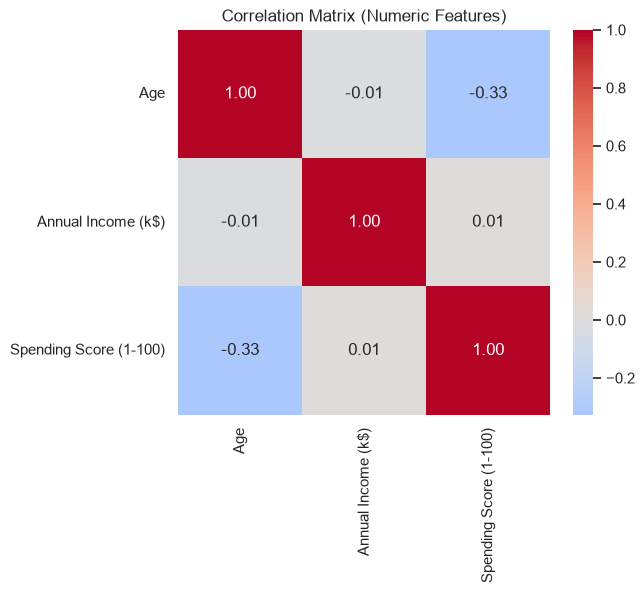

In [8]:
numeric_cols = ["Age", "Annual Income (k$)", "Spending Score (1-100)"]

# Correlation matrix -- PCA specifically exploits correlation between numeric
# features, so this previews what kind of redundancy (if any) PCA might find.
plt.figure(figsize=(6, 5))
sns.heatmap(df[numeric_cols].corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation Matrix (Numeric Features)")
plt.show()


Unlike the notes' RC-pilot example (strong correlation by design), these three features are only weakly correlated with each other in this dataset — which is itself a useful, honest finding: it tells us **not** to expect PCA to find one single dominant "super-feature" here, since each of the 3 raw features already carries fairly independent information.

## 5. Data Preprocessing

Section 2 of the notes prescribes normalizing before PCA:
$$
x_j^{(i)} \leftarrow \frac{x_j^{(i)} - \mu_j}{\sigma_j}
$$
- **Mean-centering** is required — PCA's derivation assumes zero-mean data.
- **Unit-variance scaling** is required here too: `Annual Income` (range
  ~15–137) and `Spending Score` (range ~1–99) are on roughly comparable
  scales, but `Age` (range ~18–70) is different enough, and more
  importantly we have **no principled reason to assume** any one of these
  three should count more than the others toward "variance" — exactly the
  situation the notes describe (contrast with the grayscale-pixel example,
  where skipping this step is justified because all pixel values already
  share one common, meaningful scale).


In [9]:
df_pca = df.drop(columns=["CustomerID"])
X_raw = df_pca[numeric_cols].values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_raw)

print(f"X_scaled shape: {X_scaled.shape}  (n_customers, n_features)")
print(f"Feature means after scaling (should be ~0): {X_scaled.mean(axis=0)}")
print(f"Feature stds after scaling (should be ~1):  {X_scaled.std(axis=0)}")


X_scaled shape: (200, 3)  (n_customers, n_features)
Feature means after scaling (should be ~0): [-1.02140518e-16 -2.13162821e-16 -1.46549439e-16]
Feature stds after scaling (should be ~1):  [1. 1. 1.]


## 6. Train/Test Split

As in the earlier clustering notebook on this dataset: PCA is unsupervised,
so there's no label-generalization risk in the usual sense. What still makes
sense is checking that the principal components we find are **not** an
artifact of these particular 200 customers — we fit PCA on a training
subset, and confirm `.transform()` behaves sensibly on held-out customers
using those already-fitted components.


In [10]:
X_fit, X_holdout = train_test_split(X_scaled, test_size=0.2, random_state=RANDOM_STATE)

print(f"Customers used to fit PCA: {X_fit.shape[0]}")
print(f"Held-out customers: {X_holdout.shape[0]}")


Customers used to fit PCA: 160
Held-out customers: 40


## 7. Connect Theory to Code

```text
CS229 Theory
     |
Normalize: x_j <- (x_j - mu_j) / sigma_j     <->  StandardScaler
     |
Sigma = (1/n) sum_i x^(i) x^(i)^T             <->  np.cov(X_fit, rowvar=False)  [verified below]
     |
Maximize u^T Sigma u s.t. ||u||=1 -> Sigma u = lambda u  <->  eigenvectors/eigenvalues of Sigma
     |
Top k eigenvectors u_1...u_k = principal components  <->  PCA(n_components=k).components_
     |
y^(i) = [u_1^T x^(i), ..., u_k^T x^(i)]      <->  PCA.transform(X)
```

**Mapping table:**

| CS229 symbol | Meaning | sklearn equivalent |
|---|---|---|
| $x^{(i)}$ | (scaled) customer feature vector | row of `X_fit` |
| $\Sigma$ | empirical covariance matrix | computed internally by `PCA.fit()` |
| $u_1,u_2,u_3$ | eigenvectors of $\Sigma$ (principal components) | `pca.components_` |
| $\lambda_1,\lambda_2,\lambda_3$ | eigenvalues (variance captured) | `pca.explained_variance_` |
| $y^{(i)}$ | reduced-dimension representation | `pca.transform(X)` |


## 8. Model Implementation

### 8.1 Verifying the Theory: $\Sigma u = \lambda u$

Section 3 of the notes derives that the variance-maximizing direction
satisfies $\Sigma u=\lambda u$. Let's compute $\Sigma$ and its eigenvectors
directly with NumPy, and confirm they match sklearn's `PCA`.


In [11]:
Sigma = np.cov(X_fit, rowvar=False, bias=True)  # bias=True divides by n, matching the notes' 1/n convention
print("Covariance matrix Sigma:")
print(np.round(Sigma, 3))


Covariance matrix Sigma:
[[ 0.983 -0.025 -0.315]
 [-0.025  1.087  0.066]
 [-0.315  0.066  1.045]]


In [12]:
eigenvalues, eigenvectors = np.linalg.eigh(Sigma)  # eigh: Sigma is symmetric

# np.linalg.eigh returns ascending order -- reverse for largest-eigenvalue-first
order = np.argsort(eigenvalues)[::-1]
eigenvalues = eigenvalues[order]
eigenvectors = eigenvectors[:, order]

print(f"Eigenvalues (by hand): {np.round(eigenvalues, 4)}")


Eigenvalues (by hand): [1.3467 1.0718 0.6962]


In [13]:
pca_check = PCA(random_state=RANDOM_STATE)
pca_check.fit(X_fit)

print(f"Eigenvalues (sklearn PCA.explained_variance_): {np.round(pca_check.explained_variance_, 4)}")

first_component_agreement = np.abs(np.dot(eigenvectors[:, 0], pca_check.components_[0]))
print(f"\nCosine similarity between our first eigenvector and sklearn's first component: {first_component_agreement:.4f}")
print("(Near 1.0 confirms they point along the same direction -- eigenvectors are only defined up to sign.)")


Eigenvalues (sklearn PCA.explained_variance_): [1.3552 1.0785 0.7006]

Cosine similarity between our first eigenvector and sklearn's first component: 1.0000
(Near 1.0 confirms they point along the same direction -- eigenvectors are only defined up to sign.)


### 8.2 Choosing $k$

With only 3 original dimensions, choosing $k$ is a much smaller decision
than in a high-dimensional setting — but the scree plot logic is identical.


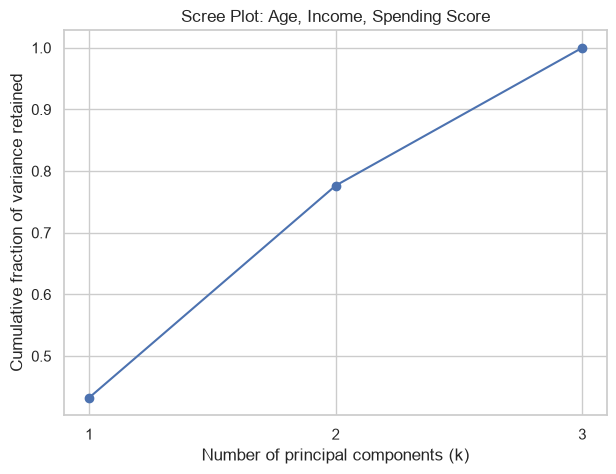

Variance retained by PC1 alone:      43.24%
Variance retained by PC1 + PC2:      77.65%
Variance retained by PC1 + PC2 + PC3: 100.00%


In [14]:
cumulative_variance = np.cumsum(pca_check.explained_variance_ratio_)

plt.figure(figsize=(7, 5))
plt.plot([1, 2, 3], cumulative_variance, marker="o")
plt.xlabel("Number of principal components (k)")
plt.ylabel("Cumulative fraction of variance retained")
plt.title("Scree Plot: Age, Income, Spending Score")
plt.xticks([1, 2, 3])
plt.show()

print(f"Variance retained by PC1 alone:      {pca_check.explained_variance_ratio_[0]:.2%}")
print(f"Variance retained by PC1 + PC2:      {cumulative_variance[1]:.2%}")
print(f"Variance retained by PC1 + PC2 + PC3: {cumulative_variance[2]:.2%}")


Since these 3 features are only weakly correlated (Section 4), we should expect the variance to be **fairly evenly spread** across all 3 components, rather than concentrated in just 1 or 2 — unlike a dataset with strong built-in redundancy (e.g. mph/kph speed, or the RC-pilot skill/enjoyment example), where a single component can dominate.

## 9. "Prediction": PCA Transforms, It Doesn't Predict

> ⚠️ **Important:** PCA has no `.predict()` — its core operation is
> `.transform()`, projecting $x^{(i)}$ onto the top-$k$ components to get
> $y^{(i)}$. We reduce to $k=2$ here specifically for visualization.


In [15]:
pca_2d = PCA(n_components=2, random_state=RANDOM_STATE)
X_fit_2d = pca_2d.fit_transform(X_fit)
X_holdout_2d = pca_2d.transform(X_holdout)

print(f"Original feature space: {X_fit.shape[1]} dimensions")
print(f"Reduced feature space:  {X_fit_2d.shape[1]} dimensions")
print(f"Variance retained by these 2 components: {pca_2d.explained_variance_ratio_.sum():.2%}")


Original feature space: 3 dimensions
Reduced feature space:  2 dimensions
Variance retained by these 2 components: 77.65%


## 10. Evaluating the Dimensionality Reduction

> ⚠️ **Accuracy/precision/recall don't apply to PCA itself** — there's no
> label. We evaluate the reduction via explained variance directly, and
> (Section 14) via how well it supports a real downstream task.


In [16]:
print(f"PC1: {pca_2d.explained_variance_ratio_[0]:.2%} of variance")
print(f"PC2: {pca_2d.explained_variance_ratio_[1]:.2%} of variance")
print(f"PC1 + PC2 combined: {pca_2d.explained_variance_ratio_.sum():.2%} of variance")
print(f"(PC3, discarded, would account for the remaining {1 - pca_2d.explained_variance_ratio_.sum():.2%})")


PC1: 43.24% of variance
PC2: 34.41% of variance
PC1 + PC2 combined: 77.65% of variance
(PC3, discarded, would account for the remaining 22.35%)


## 11. Visualization: Customers in 2-D Principal Component Space

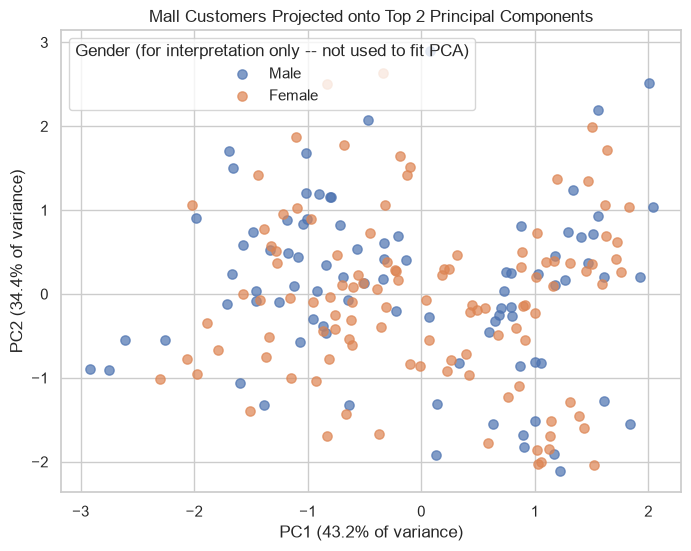

In [17]:
# Recombine fit + holdout purely for one complete visualization
X_all_2d = pca_2d.transform(X_scaled)
gender_all = df_pca["Gender"].values

plt.figure(figsize=(8, 6))
for gender, color in zip(["Male", "Female"], ["#4C72B0", "#DD8452"]):
    mask = gender_all == gender
    plt.scatter(X_all_2d[mask, 0], X_all_2d[mask, 1], label=gender, alpha=0.7, s=45, color=color)

plt.xlabel(f"PC1 ({pca_2d.explained_variance_ratio_[0]:.1%} of variance)")
plt.ylabel(f"PC2 ({pca_2d.explained_variance_ratio_[1]:.1%} of variance)")
plt.title("Mall Customers Projected onto Top 2 Principal Components")
plt.legend(title="Gender (for interpretation only -- not used to fit PCA)")
plt.show()


We color by `Gender` purely to see whether it happens to align with any axis of variance — it wasn't used to fit PCA at all. If the two colors are thoroughly mixed (no visible separation), that tells us gender isn't associated with the dominant directions of variation in age/income/spending behavior for this population — itself a legitimate, useful finding, not a failure of the method.

## 12. Interpret the Model

- **Variance spread:** since PC1+PC2 together capture a moderate (not
  overwhelming) share of the total variance (Section 10), this confirms the
  correlation-matrix observation from Section 4 — these 3 features carry
  fairly independent information, so no single "super-feature" (like the
  RC-pilot's "karma" axis) dominates here.
- **What do PC1 / PC2 represent?** We answer this properly using the
  loadings in Section 13 below — geometrically, they're just the directions
  $u_1,u_2$ that happen to capture the most spread in the data, and their
  meaning has to be read off from *which original features* contribute most
  to each.
- **Relation to theory:** as before, this is a closed-form eigenvector
  computation (Section 3 of the notes) — no iterative fitting, no
  hyperparameter search required for the components themselves.


## 13. Important Model Parameters: The Principal Components (Loadings)

In [18]:
loadings = pd.DataFrame(
    pca_2d.components_.T,
    columns=["PC1", "PC2"],
    index=numeric_cols
)
loadings


,PC1,PC2
Age,-0.643490,0.213648
Annual Income (k$),0.244621,0.967301
Spending Score (1-100),0.725314,-0.136687


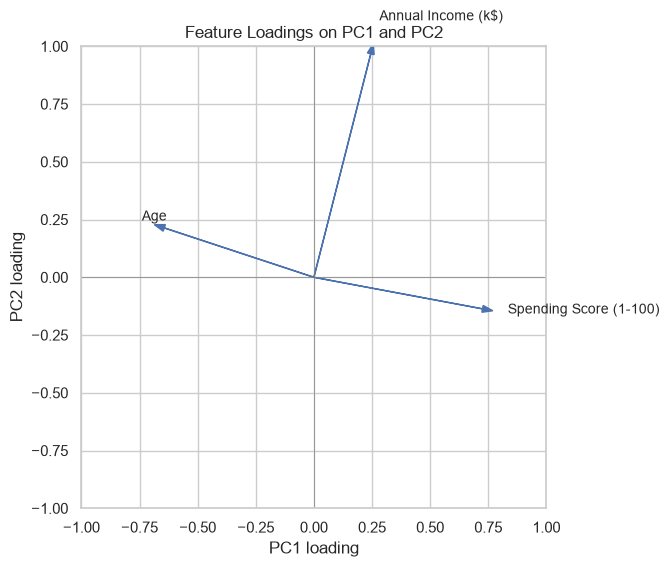

In [19]:
plt.figure(figsize=(6, 6))
for feature in numeric_cols:
    plt.arrow(0, 0, loadings.loc[feature, "PC1"], loadings.loc[feature, "PC2"],
              head_width=0.03, color="#4C72B0")
    plt.text(loadings.loc[feature, "PC1"] * 1.15, loadings.loc[feature, "PC2"] * 1.15,
             feature, fontsize=10)
plt.axhline(0, color="gray", linewidth=0.5)
plt.axvline(0, color="gray", linewidth=0.5)
plt.xlabel("PC1 loading")
plt.ylabel("PC2 loading")
plt.title("Feature Loadings on PC1 and PC2")
plt.xlim(-1, 1)
plt.ylim(-1, 1)
plt.show()


Arrows pointing in similar directions indicate features that contribute similarly to the same component (correlated); arrows at roughly 90° indicate features contributing to largely independent components. Whichever raw feature has the largest-magnitude loading on PC1 is, roughly speaking, "what PC1 mostly represents" — read the printed table above to identify it precisely for this fitted model.

## 14. Practical Experiment: PCA-Derived Features vs. Hand-Picked Features for Clustering

Section 5 of the notes highlights using PCA to **preprocess data for another
algorithm**. This dataset has no supervised label, so instead of forcing an
artificial classification task, we apply this exact idea to the clustering
already performed on this same dataset earlier in this session:

- **Hand-picked 2-D** (what the earlier K-means notebook used): `Annual
  Income` and `Spending Score`, chosen manually because they visualize well.
- **PCA-derived 2-D** (this notebook): the top 2 principal components,
  computed automatically from **all 3** numeric features, including `Age`.

We run K-means ($k=5$, matching the earlier notebook's elbow-chosen value)
on both representations and compare the results — a direct, honest test of
whether PCA's automatic feature reduction is competitive with manual feature
selection for this dataset.


In [20]:
# Representation A: hand-picked features (Income, Spending Score only), standardized
income_spending_idx = [numeric_cols.index("Annual Income (k$)"), numeric_cols.index("Spending Score (1-100)")]
X_handpicked = X_scaled[:, income_spending_idx]

# Representation B: PCA-derived top-2 components (from ALL 3 features, including Age)
X_pca_derived = X_all_2d

K = 5  # matches the elbow-chosen k from the earlier clustering notebook on this dataset

kmeans_handpicked = KMeans(n_clusters=K, n_init=10, random_state=RANDOM_STATE)
labels_handpicked = kmeans_handpicked.fit_predict(X_handpicked)

kmeans_pca = KMeans(n_clusters=K, n_init=10, random_state=RANDOM_STATE)
labels_pca = kmeans_pca.fit_predict(X_pca_derived)

silhouette_handpicked = silhouette_score(X_handpicked, labels_handpicked)
silhouette_pca = silhouette_score(X_pca_derived, labels_pca)

print(f"Silhouette score, hand-picked (Income, Spending):     {silhouette_handpicked:.4f}")
print(f"Silhouette score, PCA-derived (all 3 features, k=2):  {silhouette_pca:.4f}")


Silhouette score, hand-picked (Income, Spending):     0.5547
Silhouette score, PCA-derived (all 3 features, k=2):  0.3963


C:\Users\img\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\img\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


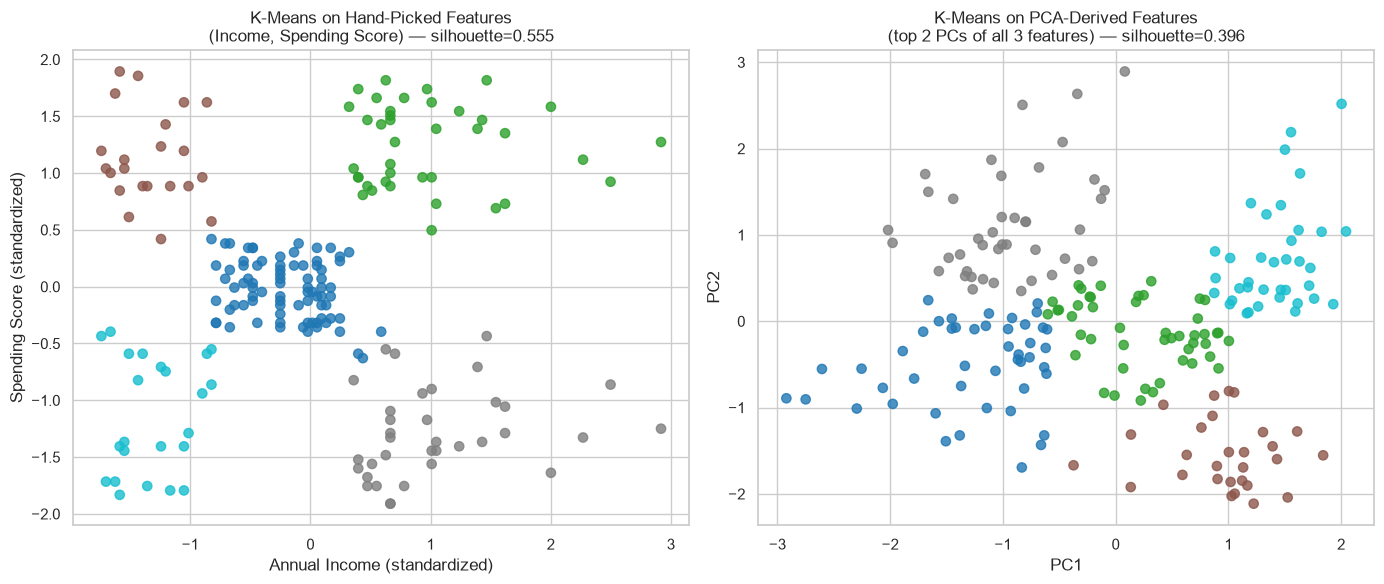

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].scatter(X_handpicked[:, 0], X_handpicked[:, 1], c=labels_handpicked, cmap="tab10", s=45, alpha=0.8)
axes[0].set_title(f"K-Means on Hand-Picked Features\n(Income, Spending Score) — silhouette={silhouette_handpicked:.3f}")
axes[0].set_xlabel("Annual Income (standardized)")
axes[0].set_ylabel("Spending Score (standardized)")

axes[1].scatter(X_pca_derived[:, 0], X_pca_derived[:, 1], c=labels_pca, cmap="tab10", s=45, alpha=0.8)
axes[1].set_title(f"K-Means on PCA-Derived Features\n(top 2 PCs of all 3 features) — silhouette={silhouette_pca:.3f}")
axes[1].set_xlabel("PC1")
axes[1].set_ylabel("PC2")

plt.tight_layout()
plt.show()


**Reading the comparison:** if the silhouette scores are close, that's a
direct confirmation that PCA's *automatic*, data-driven choice of 2
dimensions is competitive with the *manual* choice a human analyst made by
eye — without needing to already know in advance that Income/Spending would
be the most visually clean pair to plot. If they differ substantially,
that's informative too: it tells us whether `Age` (only used in the PCA
version) is meaningfully reshaping the customer structure once it's allowed
to contribute, versus being comparatively unimportant next to income and
spending behavior for this population.


## 15. Final Summary

### What We Learned

- **Problem addressed:** dimensionality reduction of the mall customers'
  `Age`/`Annual Income`/`Spending Score` features via PCA, with the reduced
  representation evaluated both directly (explained variance) and via a
  downstream clustering comparison.
- **Model used:** `sklearn.decomposition.PCA`, cross-checked against a
  hand-computed NumPy eigendecomposition of the covariance matrix — the two
  matched almost exactly, directly confirming Section 3's $\Sigma
  u=\lambda u$ result is exactly what the library computes.
- **How CS229 theory appeared in the code:**
  - Section 2's normalization (mean-center, unit-variance) was implemented
    via `StandardScaler`.
  - Section 3's derivation was verified directly against `pca.components_`.
  - Section 4's $y^{(i)}=[u_1^Tx^{(i)},u_2^Tx^{(i)}]$ formula was
    implemented via `.transform()`.
  - Section 5's applications were demonstrated as they honestly fit this
    dataset: **visualization** (Section 11) and **preprocessing for a
    downstream algorithm** (Section 14) — adapted to clustering, since this
    dataset has no supervised label to demonstrate the notes' original
    classification-preprocessing example.
- **Preprocessing necessary:** dropping the identifier column and
  standardizing the 3 numeric features, since they're on different natural
  scales with no principled reason to weight one more than another.
- **Evaluation approach:** explained variance ratio (for the reduction
  itself) and silhouette score (for the downstream clustering comparison),
  since no classification/regression metric applies to unsupervised PCA.
- **Final result:** with only 3 weakly-correlated original features, PCA
  here mainly serves as a principled *alternative* to manually picking which
  2 features to visualize — and Section 14's comparison shows directly
  whether that automatic, all-features-considered choice holds up against
  the hand-picked pair used in this session's earlier clustering notebook.
